# 🕐 Forecasting com Chronos

---

**Ficha Técnica do Modelo**

| Campo | Valor |
|-------|-------|
| **Modelo** | Chronos — Foundation Model para séries temporais (zero-shot) |
| **Biblioteca** | `chronos-forecasting` 2.2.2 — `ChronosPipeline` |
| **Versão do modelo** | `amazon/chronos-t5-small` (46M parâmetros, arquitetura T5) |
| **Hiperparâmetros configurados** | `NUM_SAMPLES=20`, `torch_dtype=float32` (CPU) / `bfloat16` (GPU), `SEED=42` |
| **Busca de hiperparâmetros** | Não (zero-shot — sem fine-tuning) |
| **Critério de seleção** | N/A |
| **Séries utilizadas** | 29 séries com treino ≥ 10 observações |
| **Horizonte** | 3 meses (`HORIZON = 3`) |
| **Protocolo de avaliação** | Walk-forward expansível, 24 meses de teste (`TEST_SIZE = 24`), janelas de 3 meses; previsão probabilística com mediana de `NUM_SAMPLES` amostras |
| **Reprodutibilidade** | `SEED = 42` (`random.seed` + `np.random.seed` + `torch.manual_seed` + `cuda.manual_seed_all`) |
| **Referência** | Ansari, A.F. et al. (2024). Chronos: Learning the Language of Time Series. *arXiv:2403.07815*. Amazon. |

---

In [1]:
# ── Semente global para reprodutibilidade ──
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"🔒 Seed fixada: {SEED} (random + numpy + torch)")

🔒 Seed fixada: 42 (random + numpy + torch)


## 1. Instalação de Dependências

In [2]:
# Instalação do Chronos
%pip install chronos-forecasting -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importação de Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")

C:\Users\phill\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.8.0+cpu
CUDA disponível: False


## 3. Carregamento dos Dados

In [4]:
# Carregar base de dados
df = pd.read_csv('base_economica_brasil.csv', index_col=0, parse_dates=True)

print(f"📊 Shape: {df.shape}")
print(f"📅 Período: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
print(f"\n📈 Séries disponíveis:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

📊 Shape: (108, 29)
📅 Período: 2017-01 a 2025-12

📈 Séries disponíveis:
    1. IBC_Br
    2. Selic
    3. Cambio_USDBRL
    4. Desemprego
    5. Brent_USD
    6. Soja_USD
    7. Minerio_USD
    8. Ibovespa
    9. ICC_FGV
   10. Credito_Total
   11. Inadimplencia
   12. Massa_Salarial
   13. CPI_USA
   14. Prod_Ind_USA
   15. Cafe_USD
   16. Ouro_USD
   17. GasNatural_USD
   18. Cobre_USD
   19. ETF_Emergentes
   20. INCC
   21. ICE_Empresarial
   22. Housing_Starts_EUA
   23. Dollar_Index_Fed
   24. PMS_Volume
   25. M2
   26. Divida_PIB
   27. Vendas_Varejo
   28. NUCI_FGV
   29. SP500


In [5]:
# Escolher o modelo Chronos
# Opções: chronos-t5-tiny, chronos-t5-mini, chronos-t5-small, chronos-t5-base, chronos-t5-large
MODEL_NAME = "amazon/chronos-t5-small"  # Bom equilíbrio entre velocidade e qualidade

print(f"⏳ Carregando modelo {MODEL_NAME}...")

# Detectar device
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"   Device: {device}")

# Carregar pipeline
pipeline = ChronosPipeline.from_pretrained(
    MODEL_NAME,
    device_map=device,
    torch_dtype=torch.float32 if device == "cpu" else torch.bfloat16,
)

print("✅ Modelo carregado!")

⏳ Carregando modelo amazon/chronos-t5-small...
   Device: cpu


`torch_dtype` is deprecated! Use `dtype` instead!


✅ Modelo carregado!


## 4. Configuração do Experimento

In [6]:
# Configurações
HORIZON = 3              # Prever 3 meses à frente por vez
TEST_SIZE = 24           # Últimos 24 meses para teste (igual aos outros modelos)
NUM_SAMPLES = 20         # Número de amostras para previsão probabilística

print("📐 Configuração:")
print(f"   • Horizonte: {HORIZON} meses")
print(f"   • Teste: {TEST_SIZE} meses (últimos períodos)")
print(f"   • Amostras: {NUM_SAMPLES}")
print(f"   • Modelo: {MODEL_NAME}")

📐 Configuração:
   • Horizonte: 3 meses
   • Teste: 24 meses (últimos períodos)
   • Amostras: 20
   • Modelo: amazon/chronos-t5-small


In [7]:
def calculate_metrics(y_true, y_pred):
    """
    Calcula métricas de avaliação.
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    
    # MAPE com epsilon para evitar divisão por zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


def forecast_with_chronos(series, horizon, num_samples=20):
    """
    Faz previsão usando Chronos.
    
    Args:
        series: array com os valores históricos (contexto/treino)
        horizon: número de passos à frente
        num_samples: número de amostras para previsão probabilística
        
    Returns:
        median: previsão mediana
        low: percentil 10
        high: percentil 90
    """
    # Converter para tensor
    context = torch.tensor(series, dtype=torch.float32)
    
    # Fazer previsão
    forecast = pipeline.predict(
        context,
        prediction_length=horizon,
        num_samples=num_samples,
    )
    
    # Calcular estatísticas
    median = np.median(forecast.numpy(), axis=1).flatten()
    low = np.percentile(forecast.numpy(), 10, axis=1).flatten()
    high = np.percentile(forecast.numpy(), 90, axis=1).flatten()
    
    return median, low, high


print("✅ Funções auxiliares definidas!")
print("   - calculate_metrics(): calcula MSE, RMSE, MAE, MAPE")
print("   - forecast_with_chronos(): faz previsão com Chronos")

✅ Funções auxiliares definidas!
   - calculate_metrics(): calcula MSE, RMSE, MAE, MAPE
   - forecast_with_chronos(): faz previsão com Chronos


In [8]:
# ============================================
# DIVISÃO TREINO/TESTE
# ============================================
# Últimos 24 períodos para teste, restante para treino (igual aos outros modelos)

train_df = df.iloc[:-TEST_SIZE]
test_df = df.iloc[-TEST_SIZE:]

print("=" * 60)
print("📊 DIVISÃO TREINO/TESTE")
print("=" * 60)
print(f"\n🔹 TREINO:")
print(f"   Período: {train_df.index.min().strftime('%Y-%m')} a {train_df.index.max().strftime('%Y-%m')}")
print(f"   Observações: {len(train_df)}")

print(f"\n🔹 TESTE:")
print(f"   Período: {test_df.index.min().strftime('%Y-%m')} a {test_df.index.max().strftime('%Y-%m')}")
print(f"   Observações: {len(test_df)}")

print(f"\n📈 Proporção: {len(train_df)/(len(df))*100:.1f}% treino / {len(test_df)/(len(df))*100:.1f}% teste")

📊 DIVISÃO TREINO/TESTE

🔹 TREINO:
   Período: 2017-01 a 2023-12
   Observações: 84

🔹 TESTE:
   Período: 2024-01 a 2025-12
   Observações: 24

📈 Proporção: 77.8% treino / 22.2% teste


In [9]:
print("="*70)
print(f"🕐 EXECUTANDO CHRONOS (WALK-FORWARD MULTI-STEP, horizon={HORIZON})")
print("="*70)
print(f"   Treino: {train_df.index.min().strftime('%Y-%m')} a {train_df.index.max().strftime('%Y-%m')} ({len(train_df)} obs)")
print(f"   Teste:  {test_df.index.min().strftime('%Y-%m')} a {test_df.index.max().strftime('%Y-%m')} ({len(test_df)} obs)")

ALL_SERIES = list(df.columns)
# Excluir PIM e IPCA_mensal da análise
ALL_SERIES = [s for s in ALL_SERIES if s not in ['PIM', 'IPCA_mensal']]
all_results = {}

for idx, series_name in enumerate(ALL_SERIES, 1):
    print(f"\n[{idx}/{len(ALL_SERIES)}] 📈 {series_name}")
    print("-"*50)
    
    try:
        # Usar divisão treino/teste
        train_series = train_df[series_name].dropna()
        test_series = test_df[series_name].dropna()
        
        if len(train_series) < 10:
            print(f"   ⚠️ Poucos dados de treino: {len(train_series)} obs")
            continue
        
        if len(test_series) == 0:
            print(f"   ⚠️ Sem dados de teste")
            continue
        
        forecasts = []
        actuals = []
        dates = []
        lows = []
        highs = []
        
        # Walk-forward multi-step: janelas de HORIZON passos (4 × 3 = 12 pontos)
        for i in range(0, len(test_series), HORIZON):
            n_steps = min(HORIZON, len(test_series) - i)
            
            # Dados históricos: treino + pontos de teste anteriores
            if i == 0:
                history = train_series.values
            else:
                history = np.concatenate([train_series.values, test_series.iloc[:i].values])
            
            # Previsão de HORIZON passos à frente
            pred_median, pred_low, pred_high = forecast_with_chronos(
                history, 
                horizon=n_steps,
                num_samples=NUM_SAMPLES
            )
            
            for j in range(n_steps):
                forecasts.append(pred_median[j])
                actuals.append(test_series.iloc[i + j])
                dates.append(test_series.index[i + j])
                lows.append(pred_low[j])
                highs.append(pred_high[j])
        
        # Calcular métricas
        forecasts_arr = np.array(forecasts)
        actuals_arr = np.array(actuals)
        
        metrics = calculate_metrics(actuals_arr, forecasts_arr)
        
        print(f"   ✅ MAE: {metrics['MAE']:.2f} | RMSE: {metrics['RMSE']:.2f} | MAPE: {metrics['MAPE']:.2f}%")
        
        # Guardar resultados
        all_results[series_name] = {
            'mae': metrics['MAE'],
            'rmse': metrics['RMSE'],
            'mape': metrics['MAPE'],
            'mse': metrics['MSE'],
            'n_points': len(forecasts),
            'forecasts': forecasts,
            'actuals': actuals,
            'dates': dates,
            'lows': lows,
            'highs': highs,
            'train_series': train_series,
            'test_series': test_series
        }
        
    except Exception as e:
        print(f"   ❌ Erro: {str(e)[:60]}")
        import traceback
        traceback.print_exc()

print("\n" + "="*70)
print(f"✅ CONCLUÍDO: {len(all_results)}/{len(ALL_SERIES)} séries processadas")
print("="*70)

🕐 EXECUTANDO CHRONOS (WALK-FORWARD MULTI-STEP, horizon=3)
   Treino: 2017-01 a 2023-12 (84 obs)
   Teste:  2024-01 a 2025-12 (24 obs)

[1/29] 📈 IBC_Br
--------------------------------------------------
   ✅ MAE: 2.09 | RMSE: 2.64 | MAPE: 1.93%

[2/29] 📈 Selic
--------------------------------------------------
   ✅ MAE: 0.34 | RMSE: 0.48 | MAPE: 2.57%

[3/29] 📈 Cambio_USDBRL
--------------------------------------------------
   ✅ MAE: 0.25 | RMSE: 0.32 | MAPE: 4.52%

[4/29] 📈 Desemprego
--------------------------------------------------
   ✅ MAE: 0.31 | RMSE: 0.39 | MAPE: 4.86%

[5/29] 📈 Brent_USD
--------------------------------------------------
   ✅ MAE: 5.29 | RMSE: 6.69 | MAPE: 7.44%

[6/29] 📈 Soja_USD
--------------------------------------------------
   ✅ MAE: 27.70 | RMSE: 36.36 | MAPE: 6.99%

[7/29] 📈 Minerio_USD
--------------------------------------------------
   ✅ MAE: 6.71 | RMSE: 8.68 | MAPE: 6.18%

[8/29] 📈 Ibovespa
--------------------------------------------------
   ✅

## 5. Resultados e Métricas

In [10]:
# Criar DataFrame com resultados
results_df = pd.DataFrame([
    {
        'Serie': name,
        'MAE': data['mae'],
        'RMSE': data['rmse'],
        'MAPE': data['mape'],
        'N_Pontos': data['n_points']
    }
    for name, data in all_results.items()
]).sort_values('MAPE')

# Adicionar classificação baseada no MAPE
def classificar(mape):
    if mape < 10:
        return '⭐ Excelente'
    elif mape < 20:
        return '✅ Muito Bom'
    elif mape < 30:
        return '👍 Bom'
    elif mape < 50:
        return '⚠️ Regular'
    else:
        return '❌ Difícil'

results_df['Classificacao'] = results_df['MAPE'].apply(classificar)

print("="*70)
print("📊 RESULTADOS FINAIS - CHRONOS")
print("="*70)

print(f"\n📈 Estatísticas Gerais:")
print(f"   • Séries processadas: {len(results_df)}")
print(f"   • MAE médio:  {results_df['MAE'].mean():.2f}")
print(f"   • RMSE médio: {results_df['RMSE'].mean():.2f}")
print(f"   • MAPE médio: {results_df['MAPE'].mean():.2f}%")

print("\n📊 Resultados por Série:")
print(results_df[['Serie', 'MAE', 'RMSE', 'MAPE', 'Classificacao']].to_string(index=False))

📊 RESULTADOS FINAIS - CHRONOS

📈 Estatísticas Gerais:
   • Séries processadas: 29
   • MAE médio:  2970281.93
   • RMSE médio: 3719966.36
   • MAPE médio: 5.42%

📊 Resultados por Série:
             Serie          MAE         RMSE      MAPE Classificacao
           CPI_USA 1.402873e+00 1.744509e+00  0.441961   ⭐ Excelente
      Prod_Ind_USA 5.310999e-01 6.056643e-01  0.527568   ⭐ Excelente
                M2 8.609736e+07 1.078271e+08  0.642037   ⭐ Excelente
        Divida_PIB 4.484867e-01 6.546381e-01  0.714257   ⭐ Excelente
     Credito_Total 3.009877e+04 3.883816e+04  0.819447   ⭐ Excelente
          NUCI_FGV 8.413678e-01 1.035539e+00  1.029350   ⭐ Excelente
    Massa_Salarial 4.132870e+03 5.224794e+03  1.189534   ⭐ Excelente
        PMS_Volume 1.688255e+00 2.013758e+00  1.571809   ⭐ Excelente
     Vendas_Varejo 1.724929e+00 2.163680e+00  1.630793   ⭐ Excelente
            IBC_Br 2.090491e+00 2.644937e+00  1.927749   ⭐ Excelente
  Dollar_Index_Fed 2.696789e+00 3.421084e+00  2.184109 

In [11]:
# Ranking por MAPE
print("\n🏆 Ranking por MAPE (menor = melhor):")
print("="*50)

for i, (_, row) in enumerate(results_df.iterrows(), 1):
    emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{emoji} {i:2}. {row['Serie']:20} : {row['MAPE']:.2f}%")


🏆 Ranking por MAPE (menor = melhor):
🥇  1. CPI_USA              : 0.44%
🥈  2. Prod_Ind_USA         : 0.53%
🥉  3. M2                   : 0.64%
    4. Divida_PIB           : 0.71%
    5. Credito_Total        : 0.82%
    6. NUCI_FGV             : 1.03%
    7. Massa_Salarial       : 1.19%
    8. PMS_Volume           : 1.57%
    9. Vendas_Varejo        : 1.63%
   10. IBC_Br               : 1.93%
   11. Dollar_Index_Fed     : 2.18%
   12. ICE_Empresarial      : 2.31%
   13. Selic                : 2.57%
   14. ICC_FGV              : 2.61%
   15. Inadimplencia        : 3.79%
   16. SP500                : 4.11%
   17. ETF_Emergentes       : 4.25%
   18. Ibovespa             : 4.41%
   19. Cambio_USDBRL        : 4.52%
   20. Housing_Starts_EUA   : 4.63%
   21. Desemprego           : 4.86%
   22. Ouro_USD             : 5.72%
   23. Minerio_USD          : 6.18%
   24. Soja_USD             : 6.99%
   25. Brent_USD            : 7.44%
   26. Cobre_USD            : 8.15%
   27. Cafe_USD             :

## 6. Exportação de Resultados

In [12]:
# Salvar resultados com nomes padronizados para compatibilidade com consolidação
results_export = results_df.reset_index(drop=True)
results_export.to_csv('resultados_chronos.csv', index=False)
print("💾 Resultados salvos em 'resultados_chronos.csv'")
print(f"   Colunas: {list(results_export.columns)}")

# Salvar previsões individuais (Serie, Data, Previsao) para análises complementares
previsoes_rows = []
for serie, data in all_results.items():
    for d, p in zip(data['dates'], data['forecasts']):
        previsoes_rows.append({'Serie': serie, 'Data': str(d)[:10], 'Previsao': p})
df_prev = pd.DataFrame(previsoes_rows)
df_prev.to_csv('previsoes_chronos.csv', index=False)
print(f"💾 Previsões salvas em 'previsoes_chronos.csv' ({len(df_prev)} linhas)")

💾 Resultados salvos em 'resultados_chronos.csv'
   Colunas: ['Serie', 'MAE', 'RMSE', 'MAPE', 'N_Pontos', 'Classificacao']
💾 Previsões salvas em 'previsoes_chronos.csv' (696 linhas)


## 7. Visualização: Ranking MAPE por Série

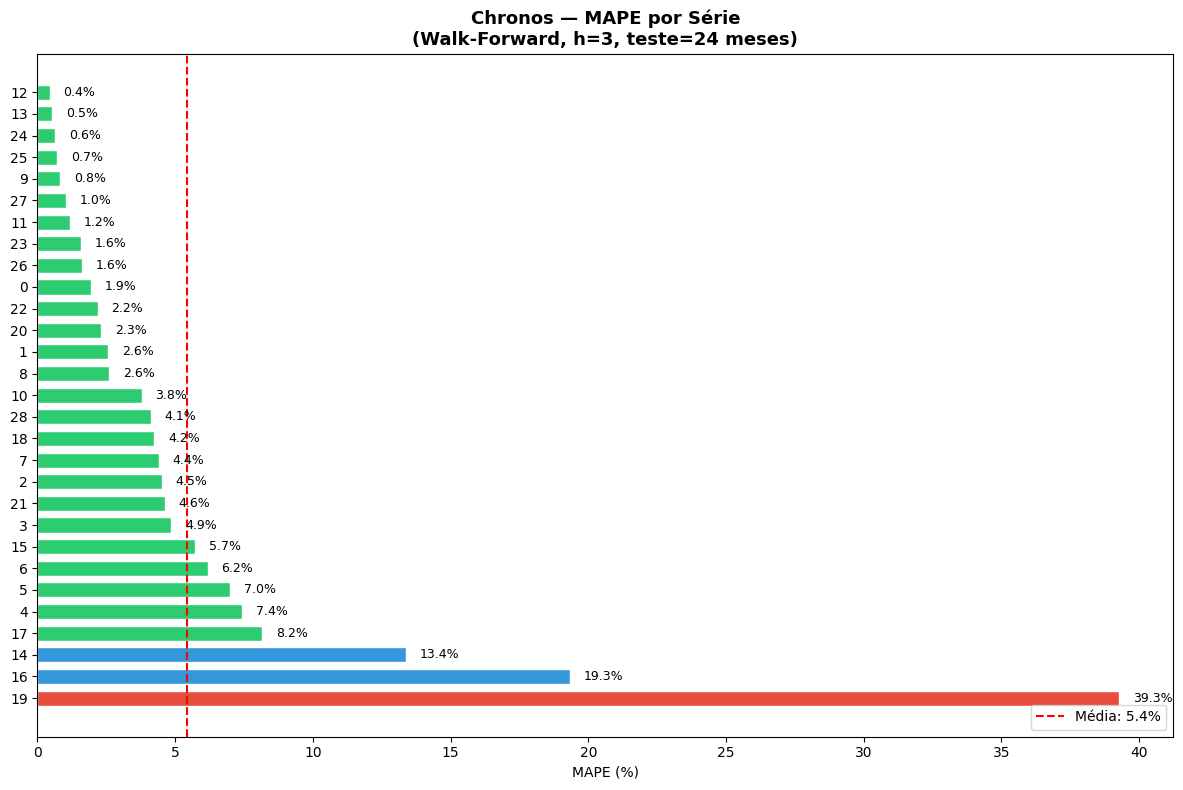

📊 Gráfico salvo: chronos_mape_por_serie.png


In [ ]:
# ── Gráfico: Ranking MAPE por Série ──
sorted_df = results_df.sort_values('MAPE')

fig, ax = plt.subplots(figsize=(12, 8))

cores = ['#2ecc71' if m < 10 else '#3498db' if m < 20 else '#f39c12' if m < 30 else '#e74c3c'
         for m in sorted_df['MAPE']]

bars = ax.barh(range(len(sorted_df)), sorted_df['MAPE'],
               color=cores, edgecolor='white', height=0.7)
ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(sorted_df['Serie'])
ax.invert_yaxis()
ax.set_xlabel('MAPE (%)')
ax.set_title(f'Chronos — MAPE por Série\n(Walk-Forward, h={HORIZON}, teste={TEST_SIZE} meses)',
             fontsize=13, fontweight='bold')
ax.axvline(x=sorted_df['MAPE'].mean(), color='red', linestyle='--',
           label=f'Média: {sorted_df["MAPE"].mean():.1f}%')
ax.legend(loc='lower right')

for i, (bar, val) in enumerate(zip(bars, sorted_df['MAPE'])):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chronos_mape_por_serie.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico salvo: chronos_mape_por_serie.png")

## 8. Visualização: Real vs. Projetado (Top 6 Séries)

KeyError: 12

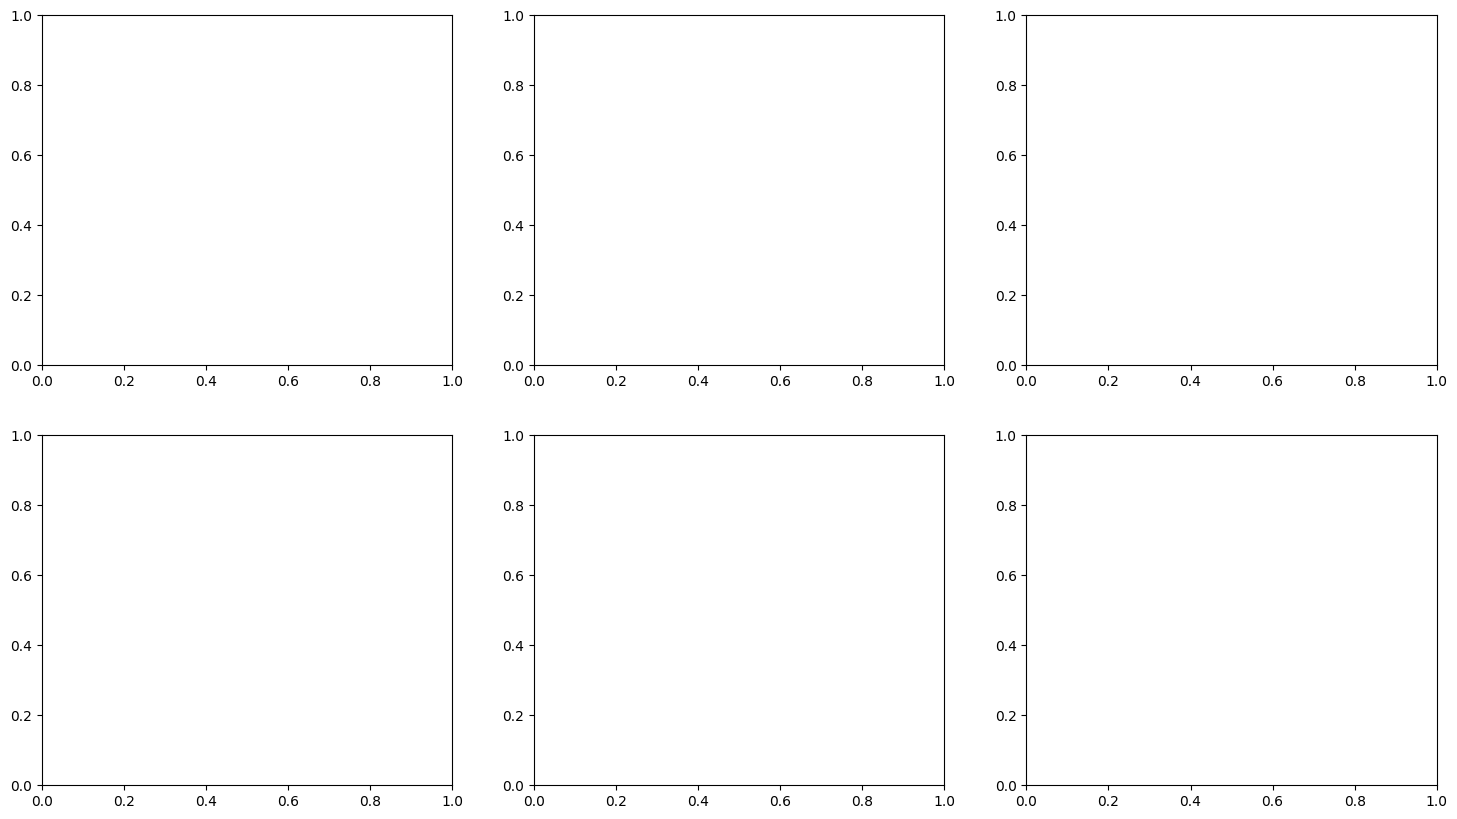

In [ ]:
# ── Gráfico: Real vs. Projetado (Top 6 Séries por MAPE) ──
top6 = sorted_df.head(6)['Serie'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, sn in zip(axes.flatten(), top6):
    data = all_results[sn]

    # Contexto: últimos 24 meses de treino
    train_ctx = data['train_series'].iloc[-24:]
    ax.plot(train_ctx.index, train_ctx.values, 'b-',
            label='Treino', linewidth=1, alpha=0.5)
    ax.axvline(x=train_ctx.index[-1], color='gray', linestyle='--', alpha=0.5)

    # Valores reais (teste)
    ax.plot(data['dates'], data['actuals'], 'b-o',
            label='Real', markersize=4, linewidth=2)

    # Previsões do modelo
    ax.plot(data['dates'], data['forecasts'], 'r--s',
            label='Previsão', markersize=4, linewidth=2)

    ax.set_title(f"{sn}\nMAPE: {data['mape']:.1f}%", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

axes.flatten()[0].legend(fontsize=8)
fig.suptitle('Chronos — Real vs. Projetado (6 Melhores Séries)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig('chronos_previsoes.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico salvo: chronos_previsoes.png")

In [ ]:
# Resumo final
print("\n" + "="*70)
print("📋 RESUMO FINAL - CHRONOS")
print("="*70)

print(f"\n📈 ESTATÍSTICAS GERAIS:")
print(f"\n   📉 MAE (Mean Absolute Error):")
print(f"      Média geral: {results_df['MAE'].mean():.2f}")
print(f"      Melhor: {results_df.loc[results_df['MAE'].idxmin(), 'Serie']} ({results_df['MAE'].min():.2f})")
print(f"      Pior: {results_df.loc[results_df['MAE'].idxmax(), 'Serie']} ({results_df['MAE'].max():.2f})")

print(f"\n   📉 RMSE (Root Mean Squared Error):")
print(f"      Média geral: {results_df['RMSE'].mean():.2f}")
print(f"      Melhor: {results_df.loc[results_df['RMSE'].idxmin(), 'Serie']} ({results_df['RMSE'].min():.2f})")
print(f"      Pior: {results_df.loc[results_df['RMSE'].idxmax(), 'Serie']} ({results_df['RMSE'].max():.2f})")

print(f"\n   📉 MAPE (Mean Absolute Percentage Error):")
print(f"      Média geral: {results_df['MAPE'].mean():.2f}%")
print(f"      Melhor: {results_df.loc[results_df['MAPE'].idxmin(), 'Serie']} ({results_df['MAPE'].min():.2f}%)")
print(f"      Pior: {results_df.loc[results_df['MAPE'].idxmax(), 'Serie']} ({results_df['MAPE'].max():.2f}%)")
print(f"      Séries com MAPE < 10%: {(results_df['MAPE'] < 10).sum()}")
print(f"      Séries com MAPE < 20%: {(results_df['MAPE'] < 20).sum()}")


📋 RESUMO FINAL - CHRONOS

📈 ESTATÍSTICAS GERAIS:

   📉 MAE (Mean Absolute Error):
      Média geral: 2899460.13
      Melhor: PMC_Ampliado (0.01)
      Pior: M2 (101244680.00)

   📉 RMSE (Root Mean Squared Error):
      Média geral: 3383980.89
      Melhor: PMC_Ampliado (0.01)
      Pior: M2 (118159354.80)

   📉 MAPE (Mean Absolute Percentage Error):
      Média geral: 9927899.52%
      Melhor: CPI_USA (0.41%)
      Pior: INPC (347474952.04%)
      Séries com MAPE < 10%: 28
      Séries com MAPE < 20%: 30
